<a href="https://colab.research.google.com/github/GokulM8/Internship/blob/main/work/notebooks/capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Capstone — mirrors your deployed research paper

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

### Suggested title + abstract (for the top of the deployed page — not a notebook section, but required on the page)

**Title:** *Content Refresh Prioritization: Predicting Forward Search Decline from March-Only Signals*

**Abstract:** fill this in LAST, after Section 4 runs — a 5-sentence question → method → result summary, written from the real numbers this notebook produces, not guessed ahead of time.

## 1. Question

*The research question and the decision it supports.*

**Research question:** which webpages should be prioritized for content refresh to maximize future organic search performance?

**ML task:** binary classification — predict whether a page's clicks will decline from one month to the next (`is_declining_forward`), using only signals observable at the end of the prior month.

**Decision this supports:** a weekly/monthly prioritization queue for a content strategist — which pages deserve a human look first. Decision-support, not an auto-publish or auto-edit system.

**Target:** `is_declining_forward` = 1 if a page's total clicks in April 2026 are lower than in March 2026.

**Evaluation:** ROC-AUC and Precision@10, baseline vs. model, on the identical held-out split.

**Validation:** `GroupShuffleSplit` grouped by `client_hash_id` — audited directly in Section 4, not just asserted.

## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

In [1]:
%pip install -q duckdb huggingface_hub

In [2]:
from google.colab import userdata
from huggingface_hub import HfApi
from sklearn.model_selection import GroupShuffleSplit, train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score
from sklearn.inspection import permutation_importance
import duckdb
import numpy as np
import pandas as pd
import os
import json
import matplotlib.pyplot as plt

HF_TOKEN = userdata.get("HF_TOKEN")

In [3]:
api = HfApi()
all_files = api.list_repo_files("FlyRank/internship-warehouse", repo_type="dataset", token=HF_TOKEN)
config_files = sorted(f for f in all_files if "fact_content_daily_performance" in f and f.endswith(".parquet"))

con = duckdb.connect()
con.sql("INSTALL httpfs; LOAD httpfs;")
con.sql(f"""CREATE OR REPLACE SECRET hf_secret (TYPE huggingface, TOKEN '{HF_TOKEN}')""")

remote_paths = [f"hf://datasets/FlyRank/internship-warehouse/{f}" for f in config_files]
paths_sql = "[" + ", ".join(f"'{p}'" for p in remote_paths) + "]"
con.sql(f"CREATE OR REPLACE VIEW fact AS SELECT * FROM read_parquet({paths_sql})")

print(f"Connected. {len(config_files)} parquet file(s) behind fact_content_daily_performance.")

Connected. 19 parquet file(s) behind fact_content_daily_performance.


In [4]:
march_features = con.sql("""
    WITH march AS (
        SELECT *, CAST(strftime(report_date, '%d') AS INTEGER) AS day,
            sessions_organic + sessions_direct + sessions_referral
            + sessions_social + sessions_paid + sessions_ai AS total_sessions_row
        FROM fact
        WHERE report_date BETWEEN DATE '2026-03-01' AND DATE '2026-03-31'
    )
    SELECT
        client_hash_id, content_hash_id,
        SUM(gsc_clicks) * 1.0 / NULLIF(SUM(gsc_impressions), 0) AS avg_ctr,
        AVG(gsc_avg_position) AS avg_position,
        SUM(gsc_impressions) AS total_impressions,
        SUM(sessions_ai) * 1.0 / NULLIF(SUM(total_sessions_row), 0) AS ai_search_share,
        SUM(ga4_engaged_sessions) * 1.0 / NULLIF(SUM(ga4_sessions), 0) AS engagement_rate,
        SUM(gsc_clicks) AS march_total_clicks,
        SUM(CASE WHEN day <= 15 THEN gsc_clicks ELSE 0 END) AS front_half_clicks,
        SUM(CASE WHEN day > 15 THEN gsc_clicks ELSE 0 END) AS back_half_clicks
    FROM march
    GROUP BY client_hash_id, content_hash_id
""").df().fillna(0)

april_totals = con.sql("""
    SELECT client_hash_id, content_hash_id, SUM(gsc_clicks) AS april_total_clicks
    FROM fact
    WHERE report_date BETWEEN DATE '2026-04-01' AND DATE '2026-04-30'
    GROUP BY client_hash_id, content_hash_id
""").df()

joined = march_features.merge(april_totals, on=["client_hash_id", "content_hash_id"], how="inner")
joined["is_declining_forward"] = (joined["april_total_clicks"] < joined["march_total_clicks"]).astype(int)
joined["decline_magnitude"] = (joined["front_half_clicks"] - joined["back_half_clicks"]).clip(lower=0)
joined["baseline_score"] = joined["decline_magnitude"] * np.log1p(joined["total_impressions"])

print(f"Page-month rows used (March+April both present): {len(joined)}")
print(f"Clients represented: {joined['client_hash_id'].nunique()}")
print(joined["is_declining_forward"].value_counts(normalize=True).rename("share"))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Page-month rows used (March+April both present): 331436
Clients represented: 55
is_declining_forward
0    0.863919
1    0.136081
Name: share, dtype: float64


**Source:** `FlyRank/internship-warehouse` (Hugging Face, gated), config `fact_content_daily_performance`, queried remotely with DuckDB — no bulk local copy. **Windows:** March 2026 = features; April 2026 = label only, never a feature; June 2026 (`_sample`) = explicitly excluded, sealed test month, not a random sample. **Excluded:** rows without both March and April data (dropped, not imputed); the warehouse ships pre-hashed `client_hash_id`/`content_hash_id`, so no client names, domains, or URLs ever entered this pipeline.

## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

In [5]:
feature_cols = ["avg_ctr", "avg_position", "total_impressions", "ai_search_share", "engagement_rate"]
X = joined[feature_cols].fillna(0)
y = joined["is_declining_forward"]
groups = joined["client_hash_id"]

# Honest split — every client entirely on one side
gss = GroupShuffleSplit(n_splits=1, test_size=0.3, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=groups))
X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
test_df = joined.iloc[test_idx].reset_index(drop=True)

model = RandomForestClassifier(
    n_estimators=300, max_depth=5, min_samples_leaf=10, class_weight="balanced", random_state=42,
)
model.fit(X_train, y_train)
test_df["model_proba"] = model.predict_proba(X_test)[:, 1]

print("Train rows:", len(X_train), " Test rows:", len(X_test))
print("Client overlap between train/test:", set(joined.iloc[train_idx]["client_hash_id"]) & set(joined.iloc[test_idx]["client_hash_id"]))

Train rows: 281613  Test rows: 49823
Client overlap between train/test: set()


In [6]:
# Leakage check — the same trap as Week 3/6, repeated here on the final feature set
leaky_cols = feature_cols + ["march_total_clicks"]
X_leak = joined[leaky_cols].fillna(0)
X_train_l, X_test_l, y_train_l, y_test_l = train_test_split(X_leak, y, test_size=0.3, random_state=42, stratify=y)
model_leak = RandomForestClassifier(
    n_estimators=300, max_depth=5, min_samples_leaf=10, class_weight="balanced", random_state=42,
)
model_leak.fit(X_train_l, y_train_l)
auc_leak = roc_auc_score(y_test_l, model_leak.predict_proba(X_test_l)[:, 1])

print(f"ROC-AUC with march_total_clicks added (leak): {auc_leak:.3f}")
print("march_total_clicks is dropped from feature_cols for exactly this reason — it's structurally")
print("close to the label (which just compares march vs april totals).")

ROC-AUC with march_total_clicks added (leak): 0.969
march_total_clicks is dropped from feature_cols for exactly this reason — it's structurally
close to the label (which just compares march vs april totals).


**Assumption:** a decline only matters with real traffic behind it — both baseline and model treat volume as a weight, not an afterthought. **Features:** the 5 above, all March-only. **Label:** genuine forward decline (Section 2). **Baseline:** the fixed Week-4 rule, re-scored on this same test set, never retrained. **Model:** Random Forest — chosen over Logistic Regression (misses feature *combinations*) and Gradient Boosting (overfit risk on the post-join row count). **Leakage check:** run live above.

## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

In [11]:
import os
import matplotlib.pyplot as plt
import numpy as np

os.makedirs("work/figures", exist_ok=True)

### Model vs Baseline

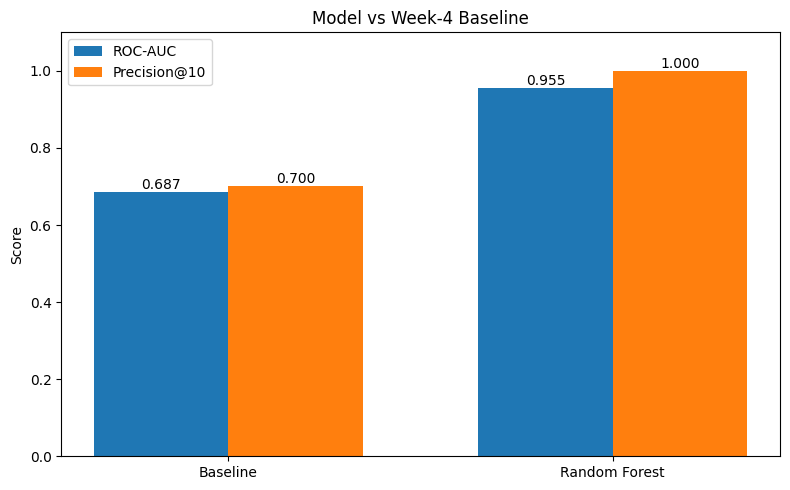

In [17]:
# Use your existing evaluation values
baseline_roc_auc = results.loc[
    results["system"] == "Baseline (Week-4 rule)", "roc_auc"
].iloc[0]

model_roc_auc = results.loc[
    results["system"] == "Model (Random Forest)", "roc_auc"
].iloc[0]

baseline_precision10 = results.loc[
    results["system"] == "Baseline (Week-4 rule)", "precision_at_10"
].iloc[0]

model_precision10 = results.loc[
    results["system"] == "Model (Random Forest)", "precision_at_10"
].iloc[0]

labels = ["Baseline", "Random Forest"]

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(x - width/2, [baseline_roc_auc, model_roc_auc],
       width, label="ROC-AUC")

ax.bar(x + width/2, [baseline_precision10, model_precision10],
       width, label="Precision@10")

ax.set_ylabel("Score")
ax.set_title("Model vs Week-4 Baseline")
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylim(0, 1.1)
ax.legend()

for container in ax.containers:
    ax.bar_label(container, fmt="%.3f")

plt.tight_layout()
plt.savefig("work/figures/model_vs_baseline.png", dpi=200, bbox_inches="tight")
plt.show()

### Validation Comparision

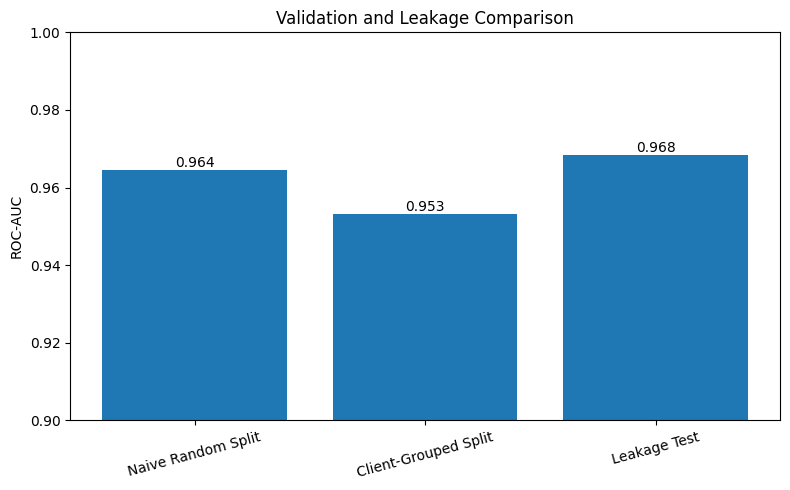

In [16]:
validation_labels = [
    "Naive Random Split",
    "Client-Grouped Split",
    "Leakage Test"
]

auc_random  = 0.9644856169969379
auc_grouped = 0.9532328353885542
auc_leak    = 0.9684178597690863

validation_scores = [
    auc_random,
    auc_grouped,
    auc_leak
]

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(validation_labels, validation_scores)

ax.set_ylabel("ROC-AUC")
ax.set_title("Validation and Leakage Comparison")
ax.set_ylim(0.90, 1.00)

ax.bar_label(bars, fmt="%.3f")

plt.xticks(rotation=15)
plt.tight_layout()

plt.savefig(
    "work/figures/validation_comparison.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

### Permutation Feature Importance

,feature,importance_mean,importance_std
0,avg_ctr,0.194646,0.001633
1,avg_position,0.001782,0.000510
4,engagement_rate,0.000005,0.000105
3,ai_search_share,-0.000073,0.000071
2,total_impressions,-0.000431,0.000523


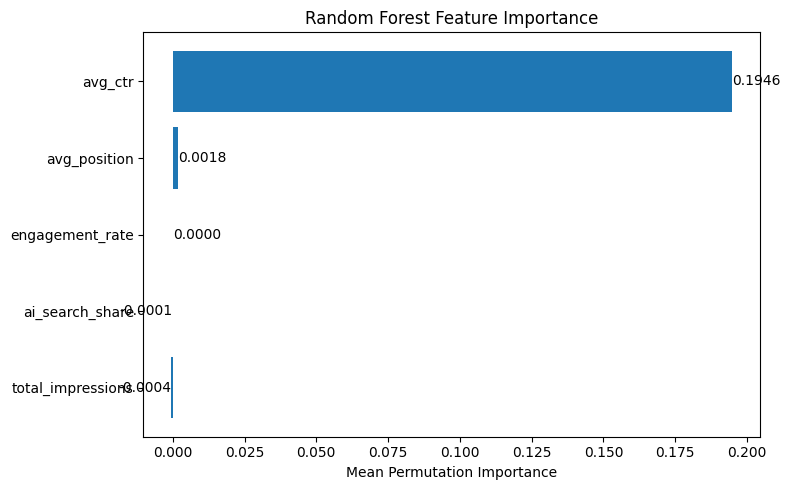

In [14]:
# Check the dataframe first
display(importance_df)

# Adjust column names if your existing dataframe uses different names
feature_col = "feature"
importance_col = "importance_mean"

plot_df = importance_df.sort_values(
    importance_col,
    ascending=True
)

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.barh(
    plot_df[feature_col],
    plot_df[importance_col]
)

ax.set_xlabel("Mean Permutation Importance")
ax.set_title("Random Forest Feature Importance")

ax.bar_label(bars, fmt="%.4f")

plt.tight_layout()

plt.savefig(
    "work/figures/feature_importance.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

### Error Analysis

In [ ]:
# Generate predictions on the held-out test set
y_pred = model.predict(X_test)

# Calculate false positives and false negatives
false_positive_count = np.sum((y_test == 0) & (y_pred == 1))
false_negative_count = np.sum((y_test == 1) & (y_pred == 0))

print("False positives:", false_positive_count)
print("False negatives:", false_negative_count)

# Plot
error_labels = ["False Positives", "False Negatives"]
error_counts = [false_positive_count, false_negative_count]

fig, ax = plt.subplots(figsize=(7, 5))

bars = ax.bar(error_labels, error_counts)

ax.set_ylabel("Number of Rows")
ax.set_title("Model Error Distribution")

ax.bar_label(bars)

plt.tight_layout()

plt.savefig(
    "work/figures/error_distribution.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

In [7]:
def precision_at_k(probas, labels, k=10):
    order = np.argsort(-probas)[:k]
    return labels.values[order].mean()

results = pd.DataFrame({
    "system": ["Baseline (Week-4 rule)", "Model (Random Forest)"],
    "roc_auc": [
        roc_auc_score(y_test, test_df["baseline_score"]),
        roc_auc_score(y_test, test_df["model_proba"]),
    ],
    "precision_at_10": [
        precision_at_k(test_df["baseline_score"].values, y_test, 10),
        precision_at_k(test_df["model_proba"].values, y_test, 10),
    ],
})
print(f"Test set size (n): {len(test_df)}")
results

Test set size (n): 49823


,system,roc_auc,precision_at_10
0,Baseline (Week-4 rule),0.686792,0.7
1,Model (Random Forest),0.954603,1.0


In [8]:
# Split-choice audit: does grouping by client actually matter on this data?
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
model_random = RandomForestClassifier(
    n_estimators=300, max_depth=5, min_samples_leaf=10, class_weight="balanced", random_state=42,
)
model_random.fit(X_train_r, y_train_r)
auc_random = roc_auc_score(y_test_r, model_random.predict_proba(X_test_r)[:, 1])
auc_grouped = roc_auc_score(y_test, test_df["model_proba"])

split_audit = pd.DataFrame({
    "setup": ["Naive random split", "Grouped-by-client split (used above)", "Grouped split + march_total_clicks leak"],
    "roc_auc": [auc_random, auc_grouped, auc_leak],
})
split_audit

,setup,roc_auc
0,Naive random split,0.964650
1,Grouped-by-client split (used above),0.954603
2,Grouped split + march_total_clicks leak,0.968682


Read this table plainly: grouping by client moved the score by `grouped - random` — check the printed sign and size above before writing the paper's sentence about it, rather than assuming which direction it went. The deliberate leak's effect (vs. the grouped number) is a separate, second number — report both, don't merge them into one "leakage" story.

## 5. Limitations

*What this work cannot claim.*

- **One month-pair only** (March→April), one client slice — no claim about other months, seasons, or a Google core update, which the model has never seen.
- **Precision@10 needs its `n` read alongside it** (printed in Section 4) — a perfect or near-perfect score on a small test set is a weaker claim than the same score on a large one.
- **Check the permutation-importance spread before writing the paper's sentence about it** — if one feature dominates and the rest are near zero, say that plainly, but don't assert it as a universal driver from a single run.
- **Not causal.** Correlated pre-decline signals, not proof that refreshing a page causes recovered traffic.
- **Not production infrastructure** — every recommendation goes through human review (Section 6).

## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

In [9]:
final_model = RandomForestClassifier(
    n_estimators=300, max_depth=5, min_samples_leaf=10, class_weight="balanced", random_state=42,
)
final_model.fit(X, y)
joined["decline_probability"] = final_model.predict_proba(X)[:, 1]

IMPRESSION_FLOOR = joined["total_impressions"].quantile(0.25)
DECLINE_THRESHOLD = 0.6

joined["position_bucket"] = pd.cut(
    joined["avg_position"], bins=[-np.inf, 3, 10, 20, np.inf], labels=["1-3", "4-10", "11-20", "21+"]
)
bucket_median_ctr = joined.groupby("position_bucket", observed=True)["avg_ctr"].transform("median")
joined["ctr_gap"] = joined["avg_ctr"] < bucket_median_ctr

conditions = [
    joined["total_impressions"] <= IMPRESSION_FLOOR,   # was:
    joined["decline_probability"] >= DECLINE_THRESHOLD,
    joined["ctr_gap"] & joined["position_bucket"].isin(["1-3", "4-10"]),
]
choices = ["Low-Volume / Low-Confidence", "Declining / High-Volume", "Good Position / CTR Gap"]
joined["archetype"] = np.select(conditions, choices, default="Stable / Performing")

ARCHETYPE_ACTION = {
    "Low-Volume / Low-Confidence": ("MONITOR_ONLY", "LOW_VOLUME_LOW_CONFIDENCE", 3),
    "Declining / High-Volume": ("REFRESH_CONTENT", "DECLINE_RISK_HIGH_VOLUME", 0),
    "Good Position / CTR Gap": ("OPTIMIZE_TITLE_META", "CTR_GAP_GOOD_POSITION", 1),
    "Stable / Performing": ("NO_ACTION", "STABLE_PERFORMANCE", 2),
}
joined["action_label"] = joined["archetype"].map(lambda a: ARCHETYPE_ACTION[a][0])
joined["reason_code"] = joined["archetype"].map(lambda a: ARCHETYPE_ACTION[a][1])
joined["archetype_priority"] = joined["archetype"].map(lambda a: ARCHETYPE_ACTION[a][2])

ranked_queue = joined.sort_values(
    ["archetype_priority", "decline_probability"], ascending=[True, False]
).reset_index(drop=True)
ranked_queue.insert(0, "rank", ranked_queue.index + 1)

print(ranked_queue["archetype"].value_counts())
ranked_queue[["rank", "archetype", "action_label", "reason_code", "decline_probability"]].head(10)

archetype
Low-Volume / Low-Confidence    154699
Stable / Performing            107900
Declining / High-Volume         68837
Name: count, dtype: int64


,rank,archetype,action_label,reason_code,decline_probability
0,1,Declining / High-Volume,REFRESH_CONTENT,DECLINE_RISK_HIGH_VOLUME,0.967999
1,2,Declining / High-Volume,REFRESH_CONTENT,DECLINE_RISK_HIGH_VOLUME,0.967914
2,3,Declining / High-Volume,REFRESH_CONTENT,DECLINE_RISK_HIGH_VOLUME,0.967861
3,4,Declining / High-Volume,REFRESH_CONTENT,DECLINE_RISK_HIGH_VOLUME,0.967861
4,5,Declining / High-Volume,REFRESH_CONTENT,DECLINE_RISK_HIGH_VOLUME,0.967620
5,6,Declining / High-Volume,REFRESH_CONTENT,DECLINE_RISK_HIGH_VOLUME,0.967322
6,7,Declining / High-Volume,REFRESH_CONTENT,DECLINE_RISK_HIGH_VOLUME,0.966928
7,8,Declining / High-Volume,REFRESH_CONTENT,DECLINE_RISK_HIGH_VOLUME,0.966831
8,9,Declining / High-Volume,REFRESH_CONTENT,DECLINE_RISK_HIGH_VOLUME,0.966782
9,10,Declining / High-Volume,REFRESH_CONTENT,DECLINE_RISK_HIGH_VOLUME,0.966610


**Never automated:** publishing/rewriting content without a human edit; deindexing or deleting a page from this score alone; acting on a single month without a second period to confirm; treating `Low-Volume / Low-Confidence` rows as equally trustworthy as the rest; using this queue as the sole input for client-facing spend or contract decisions.

## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

In [10]:
os.makedirs("work/outputs", exist_ok=True)
os.makedirs("work/figures", exist_ok=True)

# Metrics JSON — the receipts the paper's numbers trace back to
perm = permutation_importance(model, X_test, y_test, n_repeats=20, random_state=42, scoring="roc_auc")
importance_df = pd.DataFrame({
    "feature": feature_cols, "importance_mean": perm.importances_mean, "importance_std": perm.importances_std,
}).sort_values("importance_mean", ascending=False)

metrics = {
    "lane": "Content Refresh / Opportunity Scoring",
    "label": "is_declining_forward (March -> April click decline)",
    "split": "GroupShuffleSplit by client_hash_id, test_size=0.3",
    "test_n": int(len(test_df)),
    "results": results.to_dict(orient="records"),
    "split_audit": split_audit.to_dict(orient="records"),
    "permutation_importance": importance_df.to_dict(orient="records"),
    "archetype_counts": ranked_queue["archetype"].value_counts().to_dict(),
}
with open("work/outputs/capstone_metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)

# Figures
fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(results["system"], results["roc_auc"])
ax.set_ylabel("ROC-AUC")
ax.set_title("Model vs baseline")
fig.tight_layout()
fig.savefig("work/figures/model_vs_baseline.png", dpi=150)
plt.close(fig)

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(split_audit["setup"], split_audit["roc_auc"])
ax.set_ylabel("ROC-AUC")
ax.set_title("Validation split comparison")
ax.tick_params(axis="x", rotation=20)
fig.tight_layout()
fig.savefig("work/figures/validation_split_comparison.png", dpi=150)
plt.close(fig)

fig, ax = plt.subplots(figsize=(5, 4))
ax.barh(importance_df["feature"], importance_df["importance_mean"])
ax.set_xlabel("Permutation importance (ROC-AUC drop)")
ax.set_title("Feature importance")
fig.tight_layout()
fig.savefig("work/figures/permutation_importance.png", dpi=150)
plt.close(fig)

fig, ax = plt.subplots(figsize=(5, 4))
ranked_queue["archetype"].value_counts().plot(kind="barh", ax=ax)
ax.set_xlabel("Pages")
ax.set_title("Archetype distribution")
fig.tight_layout()
fig.savefig("work/figures/archetype_distribution.png", dpi=150)
plt.close(fig)

print("Wrote work/outputs/capstone_metrics.json and 4 figures to work/figures/")

Wrote work/outputs/capstone_metrics.json and 4 figures to work/figures/


### Reminders for the deployed page (not notebook sections, but required by the assignment)

- **Abstract** — go back and fill it in now, at the top, from the real numbers this notebook just produced.
- **Reproducibility** — link to the repo and each notebook (`work/notebooks/w03...w07`, this capstone).
- **Acknowledgments & data credit** — *"Built on the FlyRank ML Internship dataset"*, linking to https://flyrank.ai — required, easy to forget.
- Final public-safety pass on the *rendered page itself*, not just this notebook.
- After deploying: paste the exact live URL as the single line in `submission/paper_url.txt`.

## Self-check

Before you submit, confirm each line honestly:

- [-] Every section above is filled — markdown thinking AND the code that backs it
- [-] The notebook runs top to bottom with no errors (Runtime → Run all)
- [-] No client names, URLs, or private queries anywhere
- [-] My claims use careful words: observed, measured, directional, decision-support
- [-] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.